# Exploring the zebra null distributions

Every waven receptive field comes with a number: `abs_max_value`, the largest
|Pearson correlation| a unit reaches anywhere in the search. That search is
enormous — 2.77 M Gabor filters times 35 (delay, duration) sweep points — so a
large maximum is guaranteed even when the unit is blind. The null distributions
say *how* large, for that unit, on that sweep, under no stimulus coupling at all.

`scripts/compute_null_distribution.py` builds them by circularly rolling each
unit's response against the stimulus and re-running the whole search on every
surrogate. Its docstring is the reference for the statistics; this notebook is
about the files it wrote, and about turning them into one significance call per
unit **across the whole session**:

1. how the tree is laid out, and what one file contains
2. what the `validate/` directory is for, and how to re-run its check
3. the per-unit statistic, and why its null is fitted rather than only counted
4. five units in full detail — surrogate histogram, observed value, fitted tail
5. pooling every probe and correcting across all ~3 100 units at once
6. how many surrogates that actually needs
7. attaching the result to the optimized RF parameters

In [1]:
import sys
from pathlib import Path

sys.path.append('..')
sys.path.append('../scripts')

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NULL_ROOT = Path('../results/zebra/nullresults')
OPT_ROOT = Path('../results/zebra/optimized')
SESSION = 'sub-830794_ses-ecephys-830794-2026-01-26-12-02-05_ecephys'

# One (trial, phase) is one complete analysis of the session. Everything from
# section 4 on runs on this one; the other three are checked against it in
# section 6.
TRIAL, PHASE = 0, '0'

# the file walked through in sections 1-2; ProbeA is also the one the validate/
# gate was run on
WALK = dict(probe='ProbeA', trial=0, phase='0')

SEED = 7                      # the sampled units of section 5 are drawn with this
Q_LEVEL = 0.05                # FDR level used throughout

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3,
                     'axes.spines.top': False, 'axes.spines.right': False})
pd.set_option('display.width', 140)
pd.set_option('display.max_columns', None)

print('modalities present:', sorted(p.name for p in NULL_ROOT.iterdir()))

modalities present: ['ephys', 'mesoscope', 'slap2']


## 1. How the tree is organised

One HDF5 file per **(session, probe, trial, phase, library)**. Nothing inside the
file identifies its place in the sweep — the *path* is the key, exactly as in the
`rawresults` tree the waven pipeline writes, so the two walk alike:

```
nullresults/<modality>/<session>/<probe>/trial_<i>/phase_<p>/lib_<id>/null__lib_<id>.h5
```

* **modality** — `ephys` here; the mesoscope and SLAP2 nulls use the same layout
  with `<signal>/<plane>` or `<signal>/<dmd>/<channel>` in place of `<probe>`
* **trial** — Zebra repeat, in the order `zebra_df()['TrialNumber'].unique()` gives
* **phase** — wavelet phase 0 or 1. The null is phase specific: a threshold from
  one does not transfer to the other
* **lib** — 10-character hash of the Gabor library parameters, so a re-run under
  changed `waven_settings` cannot overwrite these results

`validate/` sits where a session name would: it is a session-shaped directory
holding the gate run of section 3, not a session.

In [2]:
def null_index(root=NULL_ROOT):
    """One row per null file, with the path decomposed into its keys."""
    rows = []
    for f in sorted(Path(root).rglob('null__lib_*.h5')):
        # depth varies by modality: the unit group (probe, signal/plane,
        # signal/dmd/channel) sits between session and the optional trial dir
        modality, session, *group, phase, lib, _ = f.relative_to(root).parts
        trial = group.pop() if group and group[-1].startswith('trial_') else None
        rows.append({'modality': modality, 'session': session, 'probe': '/'.join(group),
                     'trial': int(trial.split('_')[1]) if trial else None,
                     'phase': phase.split('_')[1],
                     'lib': lib.split('_')[1], 'MB': round(f.stat().st_size / 1e6, 1),
                     'path': f})
    return pd.DataFrame(rows)


idx = null_index()
print(f'{len(idx)} null files\n')
print(idx.groupby(['modality', 'session']).agg(files=('path', 'size'),
                                               probes=('probe', 'nunique'),
                                               MB=('MB', 'sum')))
idx.drop(columns='path').head(6)

66 null files

                                                              files  probes     MB
modality  session                                                                 
ephys     sub-830794_ses-ecephys-830794-2026-01-26-12-02-...     24       6  990.8
          validate                                                2       1    0.4
mesoscope sub-832700_ses-multiplane-ophys-832700-2026-01-...     32       8  777.7
slap2     sub-829704_ses-829704-2025-12-18-10-57-36_image...      8       4   39.8


,modality,session,probe,trial,phase,lib,MB
0,ephys,sub-830794_ses-ecephys-830794-2026-01-26-12-02...,ProbeA,0.0,0,ab4a70858e,38.3
1,ephys,sub-830794_ses-ecephys-830794-2026-01-26-12-02...,ProbeA,0.0,1,ab4a70858e,38.2
2,ephys,sub-830794_ses-ecephys-830794-2026-01-26-12-02...,ProbeA,1.0,0,ab4a70858e,38.4
3,ephys,sub-830794_ses-ecephys-830794-2026-01-26-12-02...,ProbeA,1.0,1,ab4a70858e,38.3
4,ephys,sub-830794_ses-ecephys-830794-2026-01-26-12-02...,ProbeB,0.0,0,ab4a70858e,30.6
5,ephys,sub-830794_ses-ecephys-830794-2026-01-26-12-02...,ProbeB,0.0,1,ab4a70858e,30.5


## 2. What one file contains

Five datasets and a set of attributes. `family_max` is the whole result; everything
else is there to say what its axes mean and what run produced it.

In [3]:
def pick(index, **keys):
    """The single path in `index` matching every key=value given."""
    mask = np.ones(len(index), dtype=bool)
    for k, v in keys.items():
        mask &= (index[k] == v).to_numpy()
    if mask.sum() != 1:
        raise LookupError(f'{mask.sum()} files match {keys}, expected exactly 1')
    return index.loc[mask, 'path'].iloc[0]


walk_path = pick(idx, session=SESSION, **WALK)
print(walk_path, '\n')

with h5py.File(walk_path) as hf:
    print('DATASETS')
    for k in hf:
        print(f'  {k:16s} {str(hf[k].shape):14s} {hf[k].dtype}')
    print('\nATTRIBUTES')
    for k, v in sorted(hf.attrs.items()):
        s = np.array2string(np.asarray(v), threshold=8, max_line_width=90) \
            if isinstance(v, np.ndarray) else v
        print(f'  {k:18s} {s}')

../results/zebra/nullresults/ephys/sub-830794_ses-ecephys-830794-2026-01-26-12-02-05_ecephys/ProbeA/trial_0/phase_0/lib_ab4a70858e/null__lib_ab4a70858e.h5 

DATASETS
  family_max       (482, 78, 301) float32
  lag_seconds      (301,)         float64
  lags             (301,)         int64
  n_spikes         (482,)         int64
  unit_ids         (482,)         object

ATTRIBUTES
  date_computed      2026-09-29
  family_axes        2
  filter_shape       [67 53 10  6 13]
  frame_period       0.0333614720307196
  grid_delays        [0.   0.   0.   ... 0.12 0.12 0.12]
  grid_durations     [0.05 0.1  0.15 ... 0.15 0.2  0.25]
  library_id         ab4a70858e
  min_lag_sec        1.0
  min_spikes         100
  movie              zebra_allen_screen_tscale_30_scale_10.mp4
  n_frames           9000
  n_surrogates       300
  nwb_trialnumber    59558.0
  phase              0
  probe              ProbeA
  session            sub-830794_ses-ecephys-830794-2026-01-26-12-02-05_ecephys
  sweep_delays 

### `family_max` — `(n_units, n_families, n_lags)`

* **lag axis.** Column `0` is the **observed** maximum; columns `1:` are the
  `n_surrogates` rolled ones. Lag 0 rides along in the same pass as the
  surrogates, so the observed statistic and its null are produced by identical
  code on an identical grid and cannot drift apart.
* **family axis.** A *family* is one (sigma, frequency) pair — the trailing
  `family_axes` axes of `filter_shape = (nx, ny, n_thetas, n_sigmas, n_freqs)`.
  Position and orientation have already been maximised over, because the stimulus
  is spatially homogeneous and those filters share a null scale. Sigma and
  frequency do not: they set the temporal autocorrelation of the filtered movie
  and so the effective sample size. Keeping them apart is what section 4 needs.
* **unit axis.** `unit_ids` — the same ids the rawresults and optimized files use.
  Fewer units than the pipeline has: `n_spikes < min_spikes` units are screened
  out, since a near-silent unit produces garbage correlations rather than an
  error. Always match by id, never by position.

Every cell of `family_max` is already a maximum over the **whole** (filter x sweep
point) search, so there is no per-file or per-sweep-point detail left to recover.

### The two grid attribute pairs

`grid_delays` / `grid_durations` list one entry per sweep point in the order the
maxima were accumulated — delays repeat across durations, so they are not the
unique values. `sweep_delays` / `sweep_durations` are the unique grid, and those
are what the observed side has to be restricted to (section 8).

### `lags` / `lag_seconds`

The roll offsets, in frames and in seconds. They are spread evenly and kept at
least `min_lag_sec` from either wrap, so neither a lag nor its wrap can leave the
response aligned with the stimulus. A roll preserves each unit's rate
autocorrelation, ISI structure and slow drift exactly, and breaks only the pairing
with the stimulus — which is all the null requires.

In [4]:
def load_null(path):
    """Everything in one null file, as a dict."""
    with h5py.File(path) as hf:
        out = {k: v for k, v in hf.attrs.items()}
        out['family_max'] = hf['family_max'][:]
        out['unit_ids'] = hf['unit_ids'][:].astype(str)
        out['n_spikes'] = hf['n_spikes'][:]
        out['lags'] = hf['lags'][:]
        out['lag_seconds'] = hf['lag_seconds'][:]
        out['path'] = Path(path)
    return out


nl = load_null(walk_path)
n_units, n_families, n_lags = nl['family_max'].shape

print(f"filter_shape {nl['filter_shape']}  family_axes {nl['family_axes']}"
      f"  -> {np.prod(nl['filter_shape'][-nl['family_axes']:])} families"
      f" of {np.prod(nl['filter_shape'][:-nl['family_axes']])} filters each")
print(f"sweep         {len(nl['sweep_delays'])} delays x "
      f"{len(nl['sweep_durations'])} durations = {len(nl['grid_delays'])} points")
print(f"family_max    {nl['family_max'].shape} = (units, families, 1 observed + "
      f"{n_lags - 1} surrogates)")
print(f"lags          {nl['lags'][:4]} ... {nl['lags'][-2:]} frames"
      f"  ({nl['lag_seconds'][1]:.1f} s smallest roll, min_lag_sec="
      f"{nl['min_lag_sec']})")
print(f"units         {n_units} with >= {nl['min_spikes']} spikes; "
      f"n_spikes {nl['n_spikes'].min()}-{nl['n_spikes'].max()}")

observed = nl['family_max'][:, :, 0]        # (units, families)
surrogate = nl['family_max'][:, :, 1:]      # (units, families, K)
print(f"\nobserved  mean {observed.mean():.4f}  max {observed.max():.4f}")
print(f"surrogate mean {surrogate.mean():.4f}  max {surrogate.max():.4f}")

worst = np.unravel_index(surrogate.argmax(), surrogate.shape)[0]
print(f"  the largest surrogate value belongs to unit "
      f"{nl['unit_ids'][worst][:8]} with {nl['n_spikes'][worst]} spikes - "
      f"see the next figure")

filter_shape [67 53 10  6 13]  family_axes 2  -> 78 families of 35510 filters each
sweep         7 delays x 5 durations = 35 points
family_max    (482, 78, 301) = (units, families, 1 observed + 300 surrogates)
lags          [ 0 30 60 90] ... [8940 8970] frames  (1.0 s smallest roll, min_lag_sec=1.0)
units         482 with >= 100 spikes; n_spikes 105-16931

observed  mean 0.0637  max 0.1546
surrogate mean 0.0635  max 0.4331
  the largest surrogate value belongs to unit 52895e11 with 115 spikes - see the next figure


Already visible in those two means: the observed maximum is barely above the
surrogate one on this probe. The per-family spread below shows why a single
threshold across families will not do — the null scale varies by ~40 % between the
smallest and largest (sigma, frequency) combination.

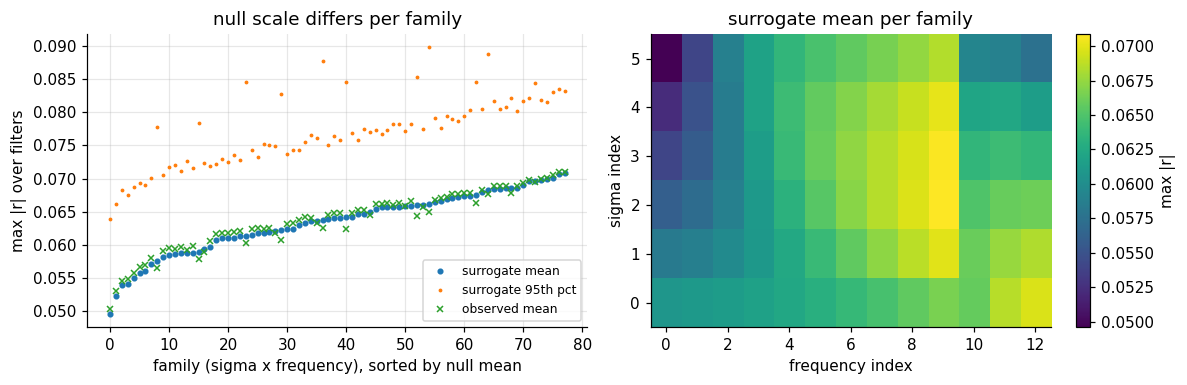

surrogate mean across families: 0.0496 to 0.0709 (ratio 1.43)


In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))

sig_idx, freq_idx = np.unravel_index(np.arange(n_families),
                                     tuple(nl['filter_shape'][-2:]))
fam_mean = surrogate.mean(axis=(0, 2))            # (families,)
order = np.argsort(fam_mean)
ax1.plot(fam_mean[order], 'o', ms=3, label='surrogate mean')
ax1.plot(np.quantile(surrogate, 0.95, axis=2).mean(0)[order], '.', ms=3,
         label='surrogate 95th pct')
ax1.plot(observed.mean(0)[order], 'x', ms=4, label='observed mean')
ax1.set(xlabel='family (sigma x frequency), sorted by null mean',
        ylabel='max |r| over filters', title='null scale differs per family')
ax1.legend(fontsize=8)

im = ax2.imshow(fam_mean.reshape(tuple(nl['filter_shape'][-2:])), aspect='auto',
                origin='lower', cmap='viridis')
ax2.set(xlabel='frequency index', ylabel='sigma index',
        title='surrogate mean per family')
plt.colorbar(im, ax=ax2, label='max |r|')
ax2.grid(False)
plt.tight_layout()
plt.show()

print('surrogate mean across families: %.4f to %.4f (ratio %.2f)'
      % (fam_mean.min(), fam_mean.max(), fam_mean.max() / fam_mean.min()))

### The null scale is a property of the unit

A quieter unit has a noisier rate vector, so its maximum over 2.77 M filters lands
higher — under the null, with no stimulus coupling whatever. That is the whole
reason the threshold is stored per unit rather than as one number for the probe:
the single largest surrogate value in this file comes from a unit with barely over
100 spikes.

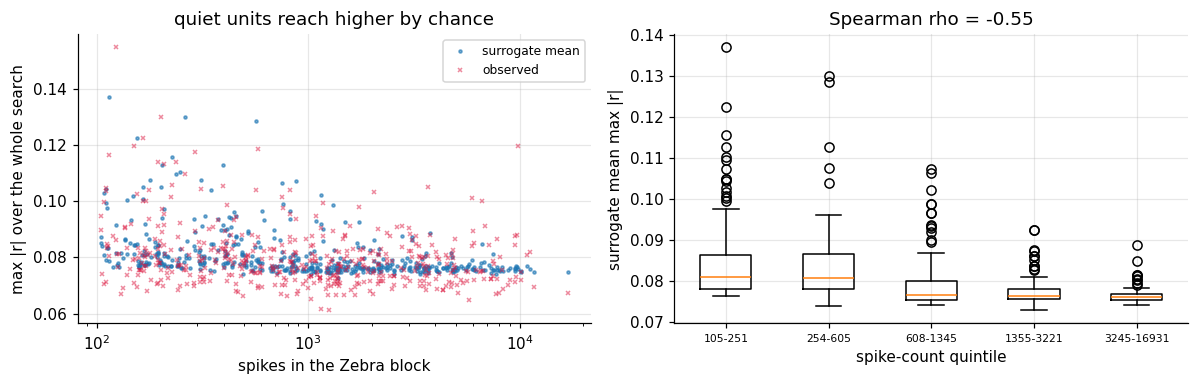

null scale, quietest quintile 0.0856  vs  busiest 0.0765
=> a single threshold for the probe would over-call the quiet units and under-call the busy ones


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))

null_scale = surrogate.max(axis=1).mean(axis=1)      # per-unit mean surrogate maximum
ax1.semilogx(nl['n_spikes'], null_scale, '.', ms=4, alpha=.6, label='surrogate mean')
ax1.semilogx(nl['n_spikes'], observed.max(axis=1), 'x', ms=3, alpha=.5,
             color='crimson', label='observed')
ax1.set(xlabel='spikes in the Zebra block', ylabel='max |r| over the whole search',
        title='quiet units reach higher by chance')
ax1.legend(fontsize=8)

rho = pd.Series(null_scale).corr(pd.Series(nl['n_spikes']), method='spearman')
decile = pd.qcut(nl['n_spikes'], 5, labels=False)
ax2.boxplot([null_scale[decile == d] for d in range(5)], tick_labels=
            [f'{int(np.min(nl["n_spikes"][decile == d]))}-'
             f'{int(np.max(nl["n_spikes"][decile == d]))}' for d in range(5)])
ax2.set(xlabel='spike-count quintile', ylabel='surrogate mean max |r|',
        title=f'Spearman rho = {rho:.2f}')
ax2.tick_params(axis='x', labelsize=7)
plt.tight_layout()
plt.show()

print(f'null scale, quietest quintile {null_scale[decile == 0].mean():.4f}  vs  '
      f'busiest {null_scale[decile == 4].mean():.4f}')
print('=> a single threshold for the probe would over-call the quiet units and '
      'under-call the busy ones')

## 3. What the `validate/` directory is for

It holds the correctness gate for the null script, not a result. The null computes
its own copy of the observed statistic (lag 0), through its own code path — a
float16 stimulus cache, a hand-rolled blocked GEMM — rather than reading the
pipeline's result files. If that copy is right, everything else the script does is
running on the same numbers the pipeline produced.

The gate is the run that makes lag 0 directly checkable:

```
N_SURROGATES=0 DELAYS=0.0 DURATIONS=0.1 PHASES=0 \
  NULL_DIR=.../nullresults/ephys/validate \
  sbatch -a 0 cluster_submission_null_zebra_ecephys.sh
```

**A single sweep point is the whole point.** `family_max[:, :, 0].max(axis=1)` is a
maximum over filters *and* over every sweep point in the grid. On a one-point grid
that is exactly what one rawresults file holds in `abs_max_value`, so the check is
a comparison against a single file. Over the full 7 x 5 grid, lag 0 would be the
maximum over all 35 files and would have to be checked against
`optimize_waven_parameters`' output instead — which is section 8, and a weaker test
because it involves that script too.

`--n-surrogates 0` costs 1/101 of a production run, and `NULL_DIR` points somewhere
else so the gate's 1-point, 0-surrogate file cannot be mistaken for a result. (The
script also guards against that: a file whose `sweep_*` or `n_surrogates`
attributes disagree with the run being asked for is recomputed rather than
skipped.)

In [7]:
gate_path = pick(idx, session='validate', probe='ProbeA', trial=0, phase='0')
gate = load_null(gate_path)

cmp = pd.DataFrame({
    'production': [nl['family_max'].shape, nl['n_surrogates'], list(nl['sweep_delays']),
                   list(nl['sweep_durations']), len(nl['grid_delays']), nl['phase'],
                   nl['date_computed']],
    'validate': [gate['family_max'].shape, gate['n_surrogates'],
                 list(gate['sweep_delays']), list(gate['sweep_durations']),
                 len(gate['grid_delays']), gate['phase'], gate['date_computed']],
}, index=['family_max shape', 'n_surrogates', 'sweep_delays', 'sweep_durations',
          'sweep points', 'phase', 'date_computed'])
print(f'{gate_path}\n')
cmp

../results/zebra/nullresults/ephys/validate/ProbeA/trial_0/phase_0/lib_ab4a70858e/null__lib_ab4a70858e.h5



,production,validate
family_max shape,"(482, 78, 301)","(482, 78, 1)"
n_surrogates,300,0
sweep_delays,"[0.0, 0.02, 0.04, 0.06, 0.08, 0.1, 0.12]",[0.0]
sweep_durations,"[0.05, 0.1, 0.15, 0.2, 0.25]",[0.1]
sweep points,35,1
phase,0,0
date_computed,2026-09-29,2026-09-27


### Running the check

The comparison wants the rawresults file for the same (probe, trial, phase) at
delay 0.0 and duration 0.1. Those files are the bulky ones and live on the cluster,
but `optimize_waven_parameters` writes `*_all_values.csv` beside every optimized
result — one row per (unit, delay, duration) with that file's `abs_max_value` — so
the same check runs off the mirrored results here.

In [8]:
def all_values(probe, trial, phase, session=SESSION, modality='ephys'):
    """The per-(unit, delay, duration) abs_max_value table for one result set."""
    stem = (f'optimized__{session}__{probe}__trial_{trial}__phase_{phase}'
            '_all_values.csv')
    return pd.read_csv(OPT_ROOT / modality / session / stem)


av = all_values(WALK['probe'], 0, 0)
print(f'{len(av)} rows, {av.unit_id.nunique()} units, '
      f'{av.delay.nunique()} delays x {av.duration.nunique()} durations')

# the one grid cell the gate was run on
raw = (av.query('delay == 0.0 and duration == 0.1')
         .set_index('unit_id')['abs_max_value'])
gate_obs = pd.Series(gate['family_max'][:, :, 0].max(axis=1), index=gate['unit_ids'])

both = pd.concat([gate_obs.rename('null_lag0'), raw.rename('rawresults')],
                 axis=1, join='inner')
diff = (both.null_lag0 - both.rawresults).abs()
print(f'\nunits compared   {len(both)}  (of {len(raw)} in the rawresults; the rest '
      f'fail the >= {gate["min_spikes"]} spike screen)')
print(f'max  abs diff    {diff.max():.2e}')
print(f'median abs diff  {diff.median():.2e}')
print(f'relative         {(diff / both.rawresults).max():.2e} worst case')
both.head(4)

43428 rows, 658 units, 13 delays x 6 durations

units compared   482  (of 658 in the rawresults; the rest fail the >= 100 spike screen)
max  abs diff    1.17e-05
median abs diff  1.65e-06
relative         1.53e-04 worst case


,null_lag0,rawresults
f06a7d7b-34c9-46e2-9355-27d03867c8d5,0.073120,0.073120
29328348-01da-49cd-b231-f43aca76905d,0.059804,0.059809
2de672bb-429a-46cc-828c-9d5114979da4,0.066709,0.066708
c9331958-49f5-4106-a982-e64881debb76,0.061990,0.061991


`~1e-5`, against a tolerance of `~1e-4`. The residual is expected, not a failure:
the stimulus cache is float16, which costs about `1e-5` on a correlation. Two
smaller differences also live in that number — `PearsonCorrelationPinkNoise`
applies `rfs -= (rfs >= 0.99)` and `nan_to_num`, which the null script does not
replicate. Irrelevant for spike data, but it would show up here if a correlation
ever reached 0.99.

If this check ever fails by more than `~1e-4`, the null and the results were
computed against different things — different library, different movie, different
frame onsets — and no p-value from them means anything.

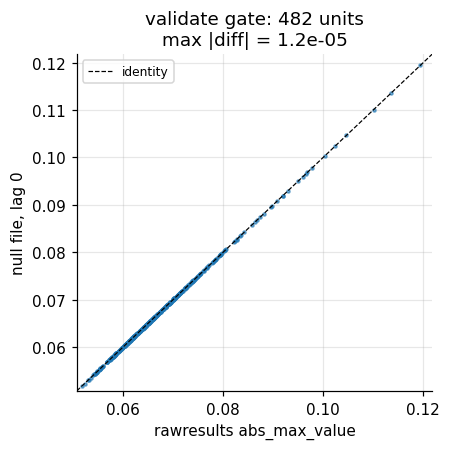

In [9]:
fig, ax = plt.subplots(figsize=(4.2, 4.2))
ax.plot(both.rawresults, both.null_lag0, '.', ms=4, alpha=.6)
lims = [both.values.min() * .98, both.values.max() * 1.02]
ax.plot(lims, lims, 'k--', lw=.8, label='identity')
ax.set(xlabel='rawresults abs_max_value', ylabel='null file, lag 0',
       title=f'validate gate: {len(both)} units\nmax |diff| = {diff.max():.1e}',
       xlim=lims, ylim=lims)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 4. The per-unit statistic, and a null that does not stop at 1/(1+K)

The statistic is one number per unit: the largest |correlation| it reaches
anywhere in the search — over every filter, every family and every sweep point.
`family_max[u, :, 0].max()` is the observed value, and `family_max[u, :, 1:].max(0)`
are the `K` surrogate values of the same quantity. Everything below is that one
column of numbers per unit.

**Counting is the obvious null, and it has a floor.** With `K` surrogates the
smallest p-value expressible is `1/(1+K)` — 0.0099 here — and every unit that
matters is pinned there. That floor is the whole problem for FDR (section 6):
BH compares the k-th smallest p against `q·k/n`, and if the smallest p cannot go
below the line, nothing is rejected no matter how strong the response is.

**So fit the tail as well as counting it.** The statistic is a maximum over a very
large number of weakly dependent quantities, and the Fisher–Tippett theorem says
such a maximum converges to one of three extreme-value laws — for light-tailed
summands, the **Gumbel**. The `K` surrogates are `K` draws from exactly that null,
so fitting a Gumbel to them and reading the observed value off the fitted tail
gives a continuous p-value, unbounded below. Method of moments, two lines:

$$\beta = s\sqrt{6}/\pi, \qquad \mu = \bar{x} - \gamma\beta, \qquad
p = 1 - \exp\!\big(-e^{-(x-\mu)/\beta}\big)$$

The fit is **per unit**: section 2 showed the null scale depends on the unit's
firing rate, so one pooled fit would be wrong for most of them.

This is extrapolation and has to be treated as such — below `1/(1+K)` nothing is
measured. Two checks keep it honest, and both are run below: the fitted p must
agree with the counted one where counting still works, and the fitted Gumbel must
actually describe the draws it was fitted to.

In [10]:
EULER = 0.5772156649015329                 # Euler-Mascheroni, for the Gumbel mean


def gumbel_mom(draws):
    """Method-of-moments Gumbel (mu, beta), one fit per ROW of `draws`."""
    beta = draws.std(axis=1, ddof=1) * np.sqrt(6) / np.pi
    return draws.mean(axis=1) - EULER * beta, beta


def gumbel_sf(x, mu, beta):
    """P(X > x) under Gumbel(mu, beta); expm1 keeps its digits when p is tiny."""
    return -np.expm1(-np.exp(-(x - mu) / beta))


def bh_fdr(p):
    """Benjamini-Hochberg adjusted p-values (q-values). See section 6."""
    p = np.asarray(p, dtype=float)
    n = len(p)
    order = np.argsort(p)
    q = np.minimum.accumulate((n / np.arange(n, 0, -1)) * p[order][::-1])[::-1]
    out = np.empty(n)
    out[order] = np.minimum(q, 1.0)
    return out


def unit_stats(path):
    """Per-unit statistic, null and p-values for one file.

    Returns (df, M_sur). `M_sur` is (n_units, K): each unit's K surrogate
    sweep-wide maxima - the histogram section 5 plots, and the sample every fit
    here is made from.
    """
    nd = load_null(path)
    fm = nd['family_max']
    obs, sur = fm[:, :, 0], fm[:, :, 1:]
    K = sur.shape[2]
    if K == 0:
        raise ValueError(f'{nd["path"]} is a validate-gate file: it holds no surrogates.')

    M_obs, M_sur = obs.max(axis=1), sur.max(axis=1)        # the statistic
    mu, beta = gumbel_mom(M_sur)

    # studentise per family first, then maximise - the variant compared below
    m, s = sur.mean(axis=2), sur.std(axis=2, ddof=1)
    T_obs = ((obs - m) / s).max(axis=1)
    T_sur = ((sur - m[:, :, None]) / s[:, :, None]).max(axis=1)
    t_mu, t_beta = gumbel_mom(T_sur)

    df = pd.DataFrame({
        'unit_id': nd['unit_ids'],
        'probe': str(nd['probe']),
        'trial': int(nd['trial']),
        'phase': str(nd['phase']),
        'n_spikes': nd['n_spikes'],
        'max_obs': M_obs,
        'null_mean': M_sur.mean(axis=1),
        'null_p95': np.quantile(M_sur, 0.95, axis=1),
        'mu': mu,
        'beta': beta,
        'p_count': (1 + (M_sur >= M_obs[:, None]).sum(axis=1)) / (1 + K),
        'p': gumbel_sf(M_obs, mu, beta),                   # the one used throughout
        'p_stud': gumbel_sf(T_obs, t_mu, t_beta),
    })
    return df, M_sur


def session_stats(trial=TRIAL, phase=PHASE, session=SESSION, q_level=Q_LEVEL):
    """Every probe of one (trial, phase), pooled into a single table.

    BH is applied HERE, over all probes at once - the family is the session, and
    that choice is what section 6 is about.
    """
    files = idx[(idx.session == session) & (idx.trial == trial) & (idx.phase == phase)]
    parts = [unit_stats(r.path) for r in files.itertuples()]
    df = pd.concat([d for d, _ in parts], ignore_index=True)
    M = np.vstack([m for _, m in parts])
    df['q'] = bh_fdr(df.p)
    df['significant'] = df.q <= q_level
    df.attrs.update(K=int(M.shape[1]), trial=trial, phase=phase,
                    q_level=q_level, n_probes=len(parts))
    return df, M


session, M_sur = session_stats()
K = session.attrs['K']
FLOOR = 1 / (1 + K)
print(f'pooled: {len(session)} units from {session.attrs["n_probes"]} probes, '
      f'trial {session.attrs["trial"]} phase {session.attrs["phase"]}, K={K}')
print(f'counting floor 1/(1+K) = {FLOOR:.4f};  '
      f'{int((session.p_count <= FLOOR).sum())} units are pinned there')
print(f'fitted p reaches {session.p.min():.1e}')
session.head(4).round(4)

pooled: 3148 units from 6 probes, trial 0 phase 0, K=300
counting floor 1/(1+K) = 0.0033;  390 units are pinned there
fitted p reaches 1.8e-54


,unit_id,probe,trial,phase,n_spikes,max_obs,null_mean,null_p95,mu,beta,p_count,p,p_stud,q,significant
0,f06a7d7b-34c9-46e2-9355-27d03867c8d5,ProbeA,0,0,2453,0.0877,0.0773,0.0906,0.0736,0.0063,0.0963,0.1006,0.0865,0.4144,False
1,29328348-01da-49cd-b231-f43aca76905d,ProbeA,0,0,1542,0.0764,0.0768,0.0908,0.0734,0.0059,0.4485,0.4486,0.4499,0.7937,False
2,2de672bb-429a-46cc-828c-9d5114979da4,ProbeA,0,0,1677,0.0775,0.0757,0.0873,0.0729,0.0048,0.3256,0.3180,0.4025,0.7156,False
3,c9331958-49f5-4106-a982-e64881debb76,ProbeA,0,0,200,0.0782,0.0785,0.0936,0.0746,0.0068,0.4352,0.4457,0.3321,0.7935,False


### Does the fit deserve the trust?

Two questions, both answerable from the data itself.

**Does it agree with counting where counting works?** Restrict to units whose
counted p is neither at the floor nor uselessly large, and compare.

**Is the statistic really Gumbel?** Each unit's own `K` draws are the sample, so
the Q-Q residual against its own fit says how well the law holds — and the sign
of the residual in the *upper* tail says which way the extrapolation errs, since
that is the part that gets extended.

The second check is also how the statistic was chosen. Studentising each family
by its own null scale before maximising is the more powerful variant (it recovers
more units), but its Gumbel fit runs **conservative** in the upper tail, while the
raw maximum's fit is unbiased exactly where the extrapolation lives. Since the
whole point here is to extrapolate past the floor, the raw maximum is what `p`
holds; `p_stud` is carried alongside so the difference stays visible.

In [11]:
def fit_quality(M):
    """Per-unit Q-Q residual against its own fit, in units of the fitted beta.

    Scale-free, so statistics with different units can be compared. The second
    return is the signed residual over the top 10 order statistics: negative
    means the draws are LIGHTER than the fit there, i.e. the fitted tail is too
    heavy and the extrapolated p is conservative.
    """
    K = M.shape[1]
    mu, beta = gumbel_mom(M)
    plotting = (np.arange(1, K + 1) - 0.5) / K
    q_theory = mu[:, None] - beta[:, None] * np.log(-np.log(plotting))[None, :]
    resid = np.sort(M, axis=1) - q_theory
    return (np.sqrt((resid ** 2).mean(axis=1)) / beta,
            resid[:, -10:].mean(axis=1) / beta)


mid = session[(session.p_count > 0.02) & (session.p_count < 0.5)]
rmse, tail = fit_quality(M_sur)
print(f'AGREEMENT with counting, on the {len(mid)} units where counting still resolves:')
print(f'  spearman(p_count, p)      {mid.p_count.corr(mid.p, method="spearman"):.3f}')
print(f'  median p / p_count        {float((mid.p / mid.p_count).median()):.2f}')
print(f'\nFIT QUALITY (residual in units of the fitted beta, over {K} draws each):')
print(f'  median Q-Q rmse           {np.median(rmse):.3f}   (90th pct {np.quantile(rmse, .9):.3f})')
print(f'  median upper-tail bias    {np.median(tail):+.3f}   '
      f'({"fit heavier than draws -> conservative" if np.median(tail) < 0 else "unbiased / optimistic"})')

print(f'\nRAW vs STUDENTISED, same units, same draws:')
for name, col in (('raw max |r|  (p)', 'p'), ('studentised (p_stud)', 'p_stud')):
    n_rej = int((bh_fdr(session[col]) <= Q_LEVEL).sum())
    print(f'  {name:22s} BH rejections {n_rej:4d}')
print(f'  rank agreement between them   '
      f'spearman {session.p.corr(session.p_stud, method="spearman"):.3f}')

AGREEMENT with counting, on the 1417 units where counting still resolves:
  spearman(p_count, p)      0.980
  median p / p_count        1.00

FIT QUALITY (residual in units of the fitted beta, over 300 draws each):
  median Q-Q rmse           0.143   (90th pct 0.284)
  median upper-tail bias    +0.039   (unbiased / optimistic)

RAW vs STUDENTISED, same units, same draws:
  raw max |r|  (p)       BH rejections  448
  studentised (p_stud)   BH rejections  477
  rank agreement between them   spearman 0.904


## 5. Individual units in detail

Units drawn at random from the pooled session (seed `SEED`, so the figure is
reproducible), plus one that is not random. Each panel shows the whole computation
for one unit:

* the **histogram** of its `K` surrogate sweep-wide maxima — the null,
* the **Gumbel** fitted to exactly those draws,
* the **observed** maximum, the value the rest of the pipeline reports as
  `abs_max_value`,
* and the three numbers that come out: the counted p, the fitted p, and the
  session-wide q from section 6.

About one unit in seven survives the correction, so a random draw is mostly null —
which is the point of looking at random units rather than chosen ones. Each panel's x-range is set by the **null**, never by the observed value. In a null
panel the red line therefore sits inside the grey histogram. A responsive unit is
tens of `beta` beyond its surrogates, and stretching the axis to reach it would
squeeze all 100 of them into a single invisible bar — so there the observed value
is marked with an arrow at the edge, labelled with how many `beta` past `mu` it
actually falls.

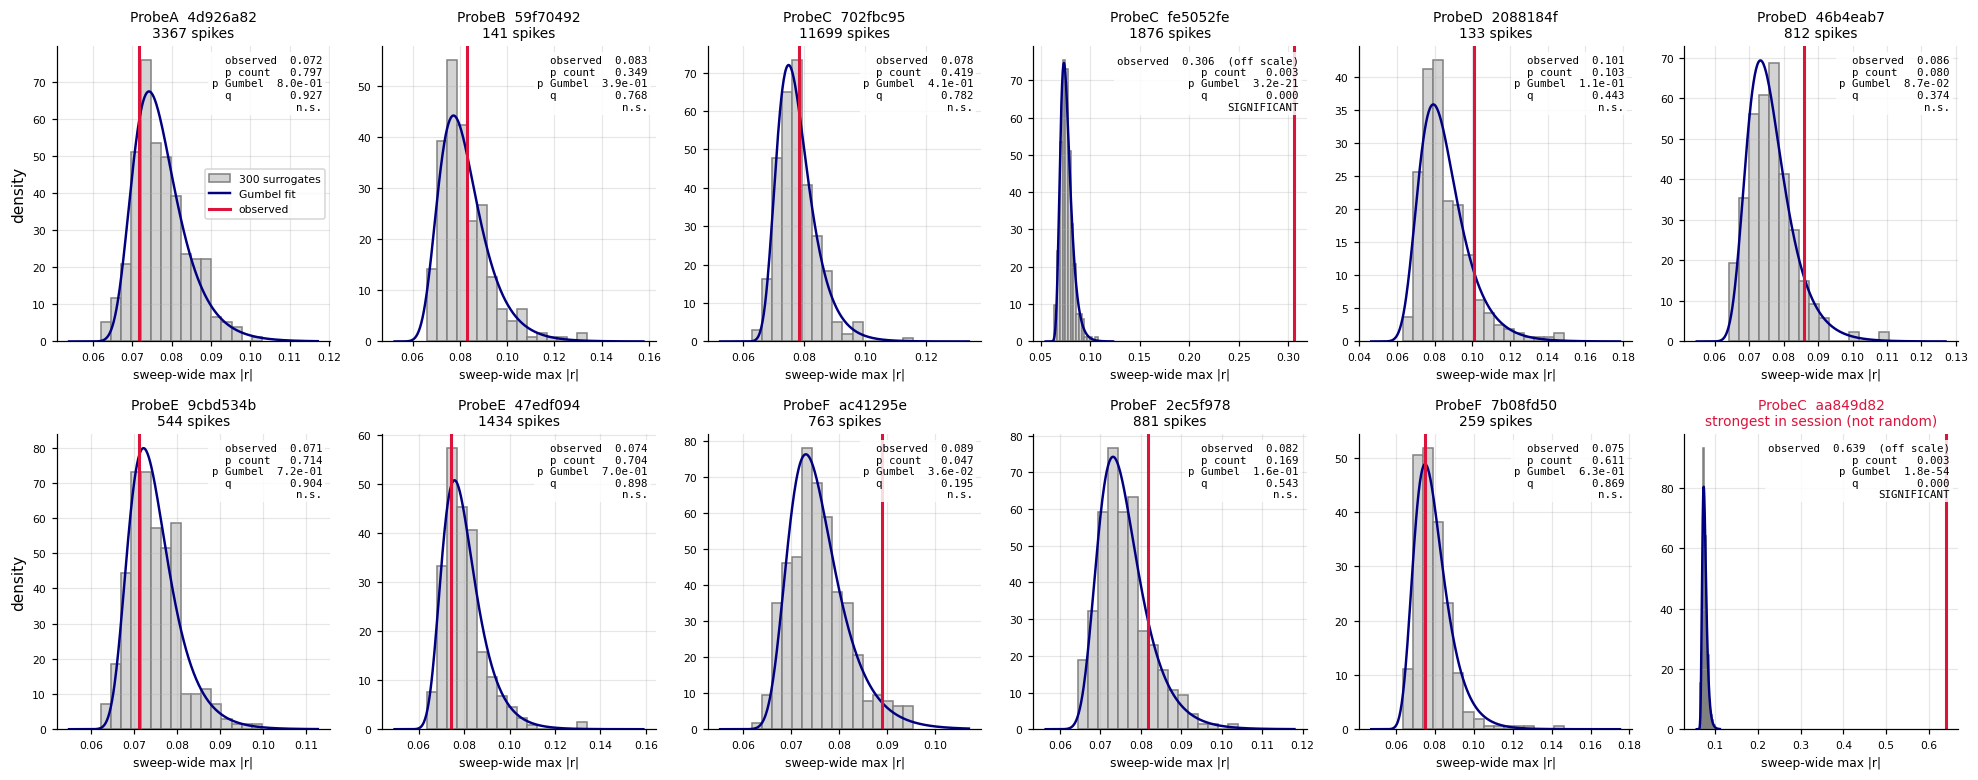

11 drawn with seed 7: rows [174, 708, 897, 944, 1816, 1962, 2148, 2437, 2620, 2818, 2965] of 3148;
plus row 915, dthe strongest unit in the session
 probe                              unit_id  n_spikes  max_obs  null_mean  p_count            p            q  significant
ProbeA 4d926a82-b00f-4884-917a-4858f3838b05      3367 0.071660   0.077399 0.797342 7.996814e-01 9.265505e-01        False
ProbeB 59f70492-f49d-4d15-8ca5-2f0f00b1c594       141 0.083205   0.082093 0.348837 3.881428e-01 7.679427e-01        False
ProbeC 702fbc95-f0c8-455a-9a49-bb44e3af20bc     11699 0.078268   0.077872 0.418605 4.052783e-01 7.816123e-01        False
ProbeC fe5052fe-40fe-4096-8519-7d686f7404d4      1876 0.306192   0.076448 0.003322 3.239830e-21 1.397121e-19         True
ProbeD 2088184f-a213-4093-b255-1664b04d5e5c       133 0.101036   0.085257 0.102990 1.133444e-01 4.433470e-01        False
ProbeD 46b4eab7-50b3-4d25-a423-b8bb6acef020       812 0.085982   0.076342 0.079734 8.726771e-02 3.737670e-01        Fals

In [12]:
rng = np.random.default_rng(SEED)
picks = np.sort(rng.choice(len(session), 11, replace=False))
# plus one that is NOT random: the strongest unit in the session, so the figure
# also shows what the other case looks like
strongest = int(session.p.values.argmin())
panels = list(picks) + [strongest]

n_panels = len(panels)
ncols = min(6, n_panels)
nrows = int(np.ceil(n_panels / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3.0 * ncols, 3.6 * nrows),
                         squeeze=False)
flat = axes.flatten()
for ax, i in zip(flat, panels):
    row = session.iloc[i]
    draws = M_sur[i]

    # The x-range is set by the NULL, not by the observed value. A responsive
    # unit sits tens of beta beyond its surrogates, and stretching the axis to
    # reach it squeezes the histogram into an invisible spike - so when the
    # observed value does not fit, it is marked at the edge instead.
    spread = draws.max() - draws.min()
    lo, hi = draws.min() - 0.2 * spread, draws.max() + 0.35 * spread
    on_scale = row.max_obs <= draws.max() + 2 * spread
    if on_scale:
        hi = max(hi, row.max_obs + 0.15 * spread)

    ax.hist(draws, bins=16, density=True, color='lightgrey', edgecolor='grey',
            label=f'{len(draws)} surrogates')
    x = np.linspace(lo, hi, 400)
    z = (x - row.mu) / row.beta
    ax.plot(x, np.exp(-(z + np.exp(-z))) / row.beta, color='navy', lw=1.6,
            label='Gumbel fit')
    # if on_scale:
    ax.axvline(row.max_obs, color='crimson', lw=2, label='observed')
    # else:
    #     # off scale: an arrow at the right edge, with how far out it actually is
    #     ax.annotate('', xy=(hi, 0.55), xytext=(hi - 0.28 * spread, 0.55),
    #                 xycoords=('data', 'axes fraction'),
    #                 textcoords=('data', 'axes fraction'),
    #                 arrowprops=dict(arrowstyle='-|>', color='crimson', lw=2))
    #     ax.text(hi, 0.63, f'observed {row.max_obs:.3f}\n'
    #                       f'= mu + {(row.max_obs - row.mu) / row.beta:.0f} beta',
    #             transform=ax.get_xaxis_transform(), ha='right', va='bottom',
    #             fontsize=7.5, color='crimson')
    # ax.set_xlim(lo, hi)

    tag = 'strongest in session (not random)' if i == strongest else f'{row.n_spikes} spikes'
    ax.set_title(f'{row.probe}  {row.unit_id[:8]}\n{tag}', fontsize=9,
                 color='crimson' if i == strongest else 'black')
    ax.set_xlabel('sweep-wide max |r|', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.text(0.97, 0.97,
            f'observed  {row.max_obs:.3f}{"" if on_scale else "  (off scale)"}\n'
            f'p count   {row.p_count:.3f}\n'
            f'p Gumbel  {row.p:.1e}\n'
            f'q         {row.q:.3f}\n'
            f'{"SIGNIFICANT" if row.significant else "n.s."}',
            transform=ax.transAxes, ha='right', va='top', fontsize=7,
            family='monospace',
            bbox=dict(facecolor='w', alpha=.85, linewidth=0, pad=2))
for ax in flat[n_panels:]:              # unused cells of the last row
    ax.axis('off')
for r in range(nrows):
    axes[r, 0].set_ylabel('density')
flat[0].legend(fontsize=7, loc='center right')
plt.tight_layout()
plt.show()

print(f'{len(picks)} drawn with seed {SEED}: rows {[int(i) for i in picks]} '
      f'of {len(session)};\nplus row {strongest}, dthe strongest unit in the session')
print(session.iloc[panels][['probe', 'unit_id', 'n_spikes', 'max_obs', 'null_mean',
                            'p_count', 'p', 'q', 'significant']].to_string(index=False))
n_sig_drawn = int(session.iloc[picks].significant.sum())
print(f'\nA fair draw: {100 * (1 - session.significant.mean()):.0f} % of this session is '
      f'not significant, and {n_sig_drawn} of the {len(picks)} random units came out '
      f'significant.')
s = session.iloc[strongest]
print(f'The last panel does not fit on the same kind of axis at all: its observed '
      f'{s.max_obs:.3f} is\n{s.max_obs / s.null_mean:.1f}x its null mean and '
      f'{(s.max_obs - s.mu) / s.beta:.0f} fitted beta past mu, so the axis is left on '
      f'the null\nand the observed value is marked at the edge. Stretching it to reach '
      f'0.64 would\ncompress all 100 surrogates into one invisible bar.')

## 6. FDR across the whole session

The per-unit p-value already accounts for everything *inside* a unit: it is the
null of a maximum over every filter and every sweep point, so no correction over
filters is owed. What it does not cover is the ~3 100 units. At `p ≤ 0.05` about
one unit in twenty passes by chance, so a correction across units goes on top,
and **Benjamini–Hochberg** is the one to use: it controls the expected fraction of
false claims among those declared significant, rather than the probability of any
false claim at all, which at this n would leave nothing.

The family here is **the whole session** — every unit on every probe, pooled. That
is a choice, and it is the strictest of the reasonable ones: pooling the mostly
silent probes in with the visual ones raises the bar for everybody. Correcting
per probe, or per anatomical structure, would be more permissive. The number
below is therefore a floor on what the session contains.

BH rejects the `k` smallest p-values where `p(k) ≤ q·k/n`. With counted
p-values that comparison is impossible here — `1/(1+K) = 0.0099` never gets below
`q·k/n` for any `k` this session has — which is exactly what the fitted tail
fixes.

In [13]:
def bh_rejections(p, q_level=Q_LEVEL):
    """How many hypotheses BH rejects, without computing every q-value."""
    p = np.sort(np.asarray(p, dtype=float))
    n = len(p)
    below = np.where(p <= q_level * np.arange(1, n + 1) / n)[0]
    return (below.max() + 1) if len(below) else 0


n = len(session)
print(f'family = the whole session: {n} units, q = {Q_LEVEL}\n')
print(f'  BH on the counted p   {bh_rejections(session.p_count):4d} rejections'
      f'   (floor {FLOOR:.4f}; BH would need the {int(np.ceil(n * FLOOR / Q_LEVEL))}th '
      f'smallest p to reach it)')
print(f'  BH on the fitted p    {bh_rejections(session.p):4d} rejections')
print(f'  units at p <= 0.05    {int((session.p <= 0.05).sum()):4d}   (uncorrected)')

by_probe = (session.groupby('probe')
                   .agg(units=('unit_id', 'size'),
                        p05=('p', lambda s: int((s <= 0.05).sum())),
                        significant=('significant', 'sum'),
                        median_obs=('max_obs', 'median'),
                        median_null=('null_mean', 'median'))
                   .assign(pct=lambda d: (100 * d.significant / d.units).round(1)))
print('\nwhere the session-wide rejections land:')
by_probe

family = the whole session: 3148 units, q = 0.05

  BH on the counted p    424 rejections   (floor 0.0033; BH would need the 210th smallest p to reach it)
  BH on the fitted p     448 rejections
  units at p <= 0.05     626   (uncorrected)

where the session-wide rejections land:


,units,p05,significant,median_obs,median_null,pct
probe,,,,,,
ProbeA,482,17,3,0.077631,0.077444,0.6
ProbeB,385,44,22,0.077465,0.076908,5.7
ProbeC,568,293,247,0.094104,0.076575,43.5
ProbeD,538,211,163,0.084840,0.077025,30.3
ProbeE,555,26,10,0.076957,0.077627,1.8
ProbeF,620,35,3,0.076942,0.076932,0.5


### The correction in one picture

BH sorts the p-values and compares the k-th smallest against the line `q·k/n`. It
rejects everything up to the **last** rank that still falls below the line — not
the first one that fails, which is what makes it a step-up procedure and why one
unit crossing back above the line does not stop the ones behind it.

Plotting both p-value flavours against that line shows the whole argument of this
notebook at once: the counted p-values are a flat shelf at `1/(1+K)` that passes
*over* the line and never comes down, while the fitted ones descend through it.

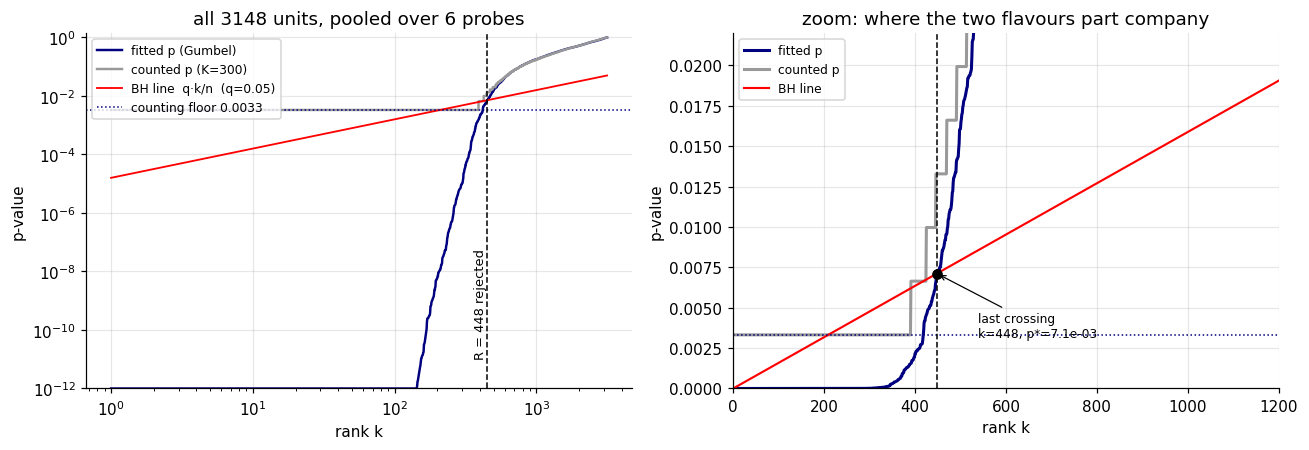

BH rejects the 448 smallest fitted p-values (p* = 7.12e-03).
The counted p-values sit at 0.0033 for their first 390 ranks, but the BH line only reaches that height at
rank 210 - beyond the 390 units that are there - so the grey curve never gets below the red one
and BH rejects nothing.


In [14]:
k = np.arange(1, n + 1)
bh_line = Q_LEVEL * k / n
p_fit = np.sort(session.p.values)
p_cnt = np.sort(session.p_count.values)
R = bh_rejections(session.p)
p_star = Q_LEVEL * R / n
CLIP = 1e-12                       # the deepest fitted p is ~1e-57; clip for display

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))

# --- full range, log-log ---
ax1.loglog(k, np.maximum(p_fit, CLIP), lw=1.6, color='navy', label='fitted p (Gumbel)')
ax1.loglog(k, p_cnt, lw=1.6, color='0.6', label=f'counted p (K={K})')
ax1.loglog(k, bh_line, 'r-', lw=1.2, label=f'BH line  q·k/n  (q={Q_LEVEL})')
ax1.axhline(FLOOR, color='navy', ls=':', lw=1,
            label=f'counting floor {FLOOR:.4f}')
ax1.axvline(R, color='k', ls='--', lw=1)
ax1.annotate(f'R = {R} rejected', xy=(R, CLIP * 10), fontsize=8.5, ha='right',
             rotation=90, va='bottom', color='k')
ax1.set(xlabel='rank k', ylabel='p-value', ylim=(CLIP, 1.4),
        title=f'all {n} units, pooled over {session.attrs["n_probes"]} probes')
ax1.legend(fontsize=8, loc='upper left')

# --- zoom on the crossing, linear ---
zoom = 1200
ax2.plot(k[:zoom], p_fit[:zoom], lw=2, color='navy', label='fitted p')
ax2.plot(k[:zoom], p_cnt[:zoom], lw=2, color='0.6', label='counted p')
ax2.plot(k[:zoom], bh_line[:zoom], 'r-', lw=1.4, label='BH line')
ax2.axhline(FLOOR, color='navy', ls=':', lw=1)
ax2.axvline(R, color='k', ls='--', lw=1)
ax2.plot([R], [p_star], 'ko', ms=6, zorder=5)
ax2.annotate(f'last crossing\nk={R}, p*={p_star:.1e}', xy=(R, p_star),
             xytext=(R + 90, p_star * 0.45), fontsize=8,
             arrowprops=dict(arrowstyle='->', lw=.8))
ax2.set(xlabel='rank k', ylabel='p-value', xlim=(0, zoom), ylim=(0, 0.022),
        title='zoom: where the two flavours part company')
ax2.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.show()

print(f'BH rejects the {R} smallest fitted p-values (p* = {p_star:.2e}).')
print(f'The counted p-values sit at {FLOOR:.4f} for their first '
      f'{int((p_cnt <= FLOOR).sum())} ranks, but the BH line only reaches that '
      f'height at\nrank {int(np.ceil(n * FLOOR / Q_LEVEL))} - beyond the '
      f'{int((p_cnt <= FLOOR).sum())} units that are there - so the grey curve '
      f'never gets below the red one\nand BH rejects nothing.')

In [15]:
# Anatomy, so the answer can be checked against something independent of the
# statistics. units_df() reads the whole spike_times dataset (~900 MB), so this
# is the one slow cell in the notebook - skip it if the session is not mirrored.
import re

NWB = Path(f'../../../rawdata/allen_open_scope/sub-830794/{SESSION}.nwb')
if NWB.exists():
    import utils
    udf = utils.open_local(str(NWB)).units_df()[['unit_name', 'location']]
    udf['unit_id'] = udf.unit_name.astype(str)
    # group layers and subdivisions: VISp2/3 -> VISp, LGd-co -> LGd, CA1 -> CA
    udf['structure'] = udf.location.astype(str).map(
        lambda s: re.sub(r'([0-9].*|-[a-z]{2,3})$', '', s))
    anno = session.merge(udf[['unit_id', 'structure']], on='unit_id', how='left')

    by_struct = (anno.dropna(subset=['structure'])
                     .groupby('structure')
                     .agg(units=('unit_id', 'size'), significant=('significant', 'sum'))
                     .query('units >= 20')
                     .assign(pct=lambda d: (100 * d.significant / d.units).round(1))
                     .sort_values('significant', ascending=False))
    print(f'{int(anno.significant.sum())} session-wide rejections, by CCF structure '
          f'(>= 20 units):')
    print(by_struct.head(12).to_string())
    print(f'\n... and {int(by_struct.iloc[8:].significant.sum())} in the remaining '
          f'{len(by_struct) - 8} structures')
else:
    anno = None
    print(f'{NWB} not mirrored here - skipping the anatomy join')

/home/marcelraabe/miniforge3/envs/waven_dandi/lib/python3.13/site-packages/hdmf/common/table.py:512: UserWarning: An attribute 'name' already exists on TimeIntervals '40 hz pulse train_presentations' so this column cannot be accessed as an attribute, e.g., table.name; it can only be accessed using other methods, e.g., table['name'].
  self.__set_table_attr(col)
/home/marcelraabe/miniforge3/envs/waven_dandi/lib/python3.13/site-packages/hdmf/common/table.py:512: UserWarning: An attribute 'name' already exists on TimeIntervals '5 hz pulse train_presentations' so this column cannot be accessed as an attribute, e.g., table.name; it can only be accessed using other methods, e.g., table['name'].
  self.__set_table_attr(col)
/home/marcelraabe/miniforge3/envs/waven_dandi/lib/python3.13/site-packages/hdmf/common/table.py:512: UserWarning: An attribute 'name' already exists on TimeIntervals 'raised_cosine_presentations' so this column cannot be accessed as an attribute, e.g., table.name; it can o

448 session-wide rejections, by CCF structure (>= 20 units):
              units  significant   pct
structure                             
VISp            222          142  64.0
LGd             121          100  82.6
LGv              73           61  83.6
VISl            141           52  36.9
or               85           22  25.9
IGL              23           17  73.9
fiber tracts     22           14  63.6
fp               22           11  50.0
MOs             657            9   1.4
CA              492            6   1.2
void             60            2   3.3
SSp-bfd         165            2   1.2

... and 29 in the remaining 21 structures


Every structure that survives is visual pathway — primary and lateral visual
cortex, the two geniculate nuclei, the intergeniculate leaflet, and the
optic-radiation fibre tracts that run between them. Hippocampus, motor and
prefrontal cortex contribute essentially nothing, and they are not small: several
hundred units each. That is the null doing its job. No internal consistency check
is as convincing as the correction declining to find receptive fields in MOs.

### The same data without the correction

For contrast, the reading that skips it. Each unit has 78 families, and asking
"did the observed value beat *any* family's own 95th percentile" is 78 chances to
be wrong:

In [16]:
# `observed` and `surrogate` are the walk file from section 2
crit = np.quantile(surrogate, 0.95, axis=2)              # (units, families)
naive = (observed > crit).any(axis=1)
walk_rows = session[(session.probe == WALK['probe'])]

print(f'{WALK["probe"]}, the same {len(walk_rows)} units three ways:')
print(f'  beats its own 95th pct in ANY of {n_families} families   '
      f'{int(naive.sum()):4d}  ({100 * naive.mean():.0f} %)')
print(f'  p <= 0.05 on the sweep-wide maximum                  '
      f'{int((walk_rows.p <= 0.05).sum()):4d}  '
      f'({100 * (walk_rows.p <= 0.05).mean():.0f} %)')
print(f'  survives BH across the whole session                 '
      f'{int(walk_rows.significant.sum()):4d}  '
      f'({100 * walk_rows.significant.mean():.0f} %)')
print('\nThe first number is why family_max keeps the family axis instead of storing')
print('one value per unit: the maximum has to be taken over families BEFORE the')
print('comparison, not after it.')

ProbeA, the same 482 units three ways:
  beats its own 95th pct in ANY of 78 families    228  (47 %)
  p <= 0.05 on the sweep-wide maximum                    17  (4 %)
  survives BH across the whole session                    3  (1 %)

The first number is why family_max keeps the family axis instead of storing
one value per unit: the maximum has to be taken over families BEFORE the
comparison, not after it.


### Peak correlation by location: significant vs. all other units

The same plot as `demo_best_ephys_gabor_rfs` (box per `location`, x labels carry
the unit count), but each location gets two boxes: the units that survive the
session-wide BH correction, and every other unit of the recording. The statistic is
`max_obs`, the sweep-wide max |r| that the test itself used (on the null's grid).
Locations are the raw CCF labels, layer suffix included, as in the demo.

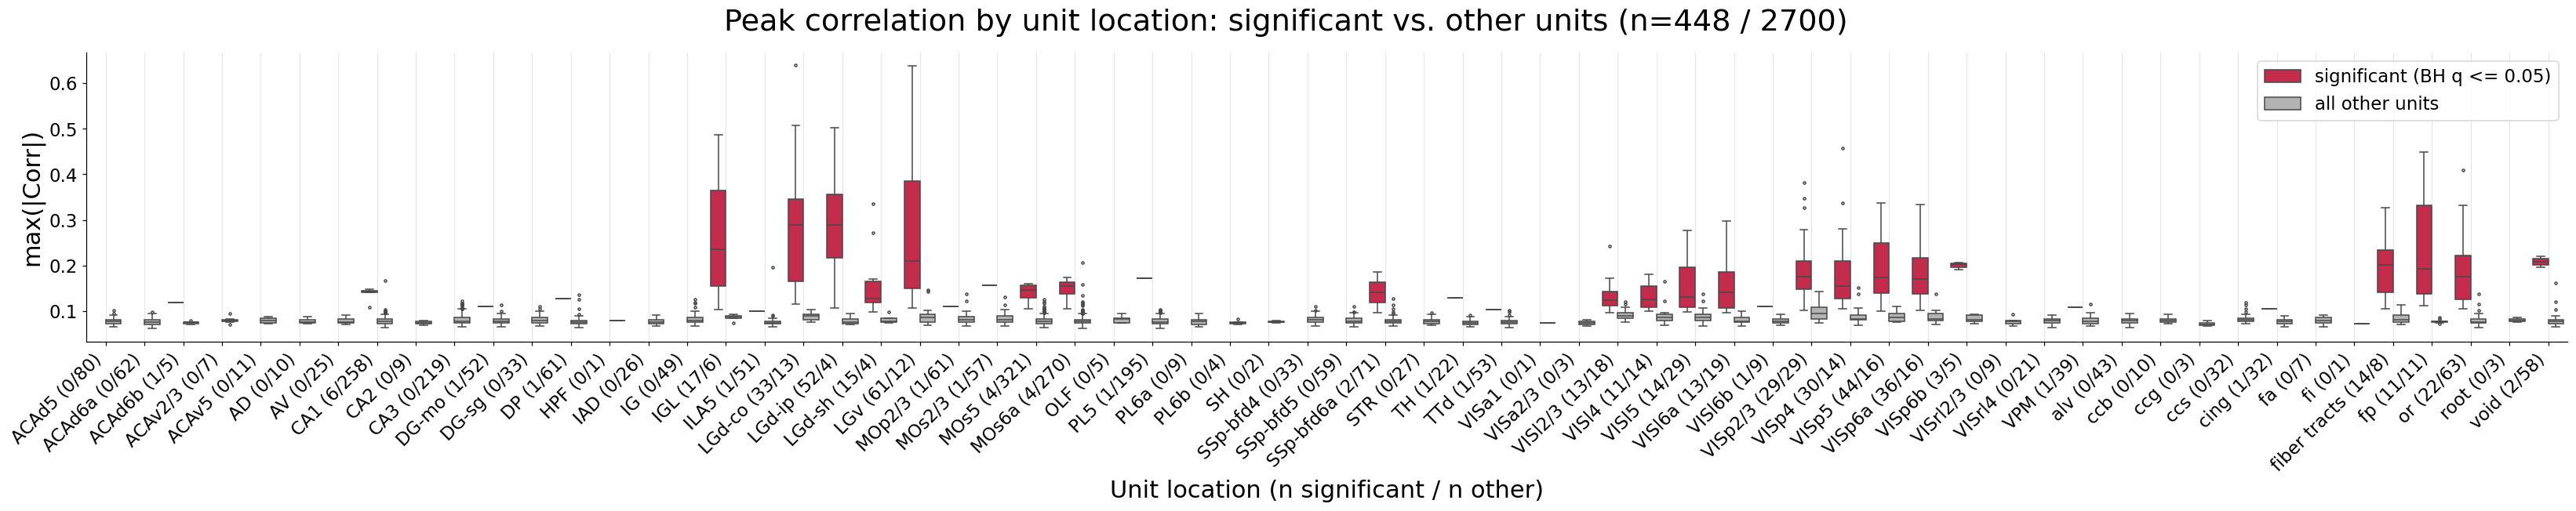

In [17]:
import seaborn as sns

# unit -> location, straight from the NWB (the same table the anatomy cell above uses)
if 'udf' not in globals() or 'location' not in udf.columns:
    import utils
    udf = utils.open_local(str(NWB)).units_df()[['unit_name', 'location']]
    udf['unit_id'] = udf.unit_name.astype(str)

loc_df = session.merge(udf[['unit_id', 'location']], on='unit_id', how='left')
loc_df = loc_df.dropna(subset=['location']).sort_values('location')
loc_df['group'] = np.where(loc_df.significant, f'significant (BH q <= {Q_LEVEL})',
                           'all other units')
hue_order = [f'significant (BH q <= {Q_LEVEL})', 'all other units']

n_sig = loc_df[loc_df.significant].location.value_counts()
n_all = loc_df.location.value_counts()
locations = sorted(n_all.index)
labels = [f'{loc} ({n_sig.get(loc, 0)}/{n_all[loc] - n_sig.get(loc, 0)})'
          for loc in locations]

fig, ax = plt.subplots(figsize=(30, 6))
sns.boxplot(data=loc_df, x='location', y='max_obs', hue='group', order=locations,
            hue_order=hue_order, palette=['crimson', '0.7'], fliersize=2, ax=ax)
ax.set_xticks(range(len(locations)))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.set_xlabel('Unit location (n significant / n other)', fontsize=20)
ax.set_ylabel('max(|Corr|)', fontsize=20)
ax.legend(fontsize=15, loc='upper right')
ax.grid()
fig.suptitle(f'Peak correlation by unit location: significant vs. other units '
             f'(n={int(loc_df.significant.sum())} / {int((~loc_df.significant).sum())})',
             fontsize=25)
fig.tight_layout()
plt.show()

### Is it stable?

Two Zebra repeats and two wavelet phases are four independent analyses of the
same session — independent surrogate draws, and for the trials independent data.
Agreement between them is evidence the correction is not describing noise.

In [ ]:
runs = {}
for tr in sorted(idx[idx.session == SESSION].trial.unique()):
    for ph in sorted(idx[idx.session == SESSION].phase.unique()):
        d, _ = session_stats(trial=int(tr), phase=str(ph))
        runs[(int(tr), str(ph))] = d

summary = pd.DataFrame([
    {'trial': t, 'phase': p, 'units': len(d),
     'p<=.05': int((d.p <= 0.05).sum()),
     'BH rejections': int(d.significant.sum()),
     'pct': round(100 * float(d.significant.mean()), 1)}
    for (t, p), d in runs.items()])
print(summary.to_string(index=False))

# units significant in all four
sig_sets = [set(d.unit_id[d.significant]) for d in runs.values()]
common = set.intersection(*sig_sets)
union = set.union(*sig_sets)
print(f'\nsignificant in all 4 (trial, phase) runs: {len(common)}')
print(f'significant in at least one          : {len(union)}')
print(f'overlap {100 * len(common) / len(union):.0f} % - the disagreement is the '
      f'marginal units, as expected')

 trial phase  units  p<=.05  BH rejections  pct
     0     0   3148     638            451 14.3
     0     1   3148     631            456 14.5
     1     0   3109     683            503 16.2
     1     1   3109     679            510 16.4

significant in all 4 (trial, phase) runs: 394
significant in at least one          : 574
overlap 69 % - the disagreement is the marginal units, as expected


## 7. How many surrogates does this need?

The fitted p made the correction possible; it also says what it would take to do
without the fit. If BH rejects `R` of `n`, the critical p at the boundary is
`p* = q·R/n`, and a counted p can only get there if

$$K \ge \frac{1}{p^*} - 1 = \frac{n}{q\,R} - 1$$

Clearing it is the bare minimum — it puts the marginal unit at exactly zero
exceedances, where its p-value is as unstable as a p-value can be. For the
boundary to be reproducible you want ~10 surrogates to land beyond `p*`, which
costs a factor of ten.

In [ ]:
R = bh_rejections(session.p)
p_star = Q_LEVEL * R / n
print(f'R = {R} rejections of n = {n}   ->   p* = q*R/n = {p_star:.2e}\n')
print(f'  bare minimum      K >= 1/p* - 1  = {int(np.ceil(1 / p_star)) - 1}')
print(f'  ~10 beyond p* (stable boundary)  = {int(np.ceil(10 / p_star))}')
print(f'  ~20 beyond p* (comfortable)      = {int(np.ceil(20 / p_star))}')

print(f'\n{"K":>7s} {"floor":>9s} {"units below":>12s} {"BH needs":>9s}   verdict')
for KK in (100, 300, 1000, 3000):
    fl = 1 / (1 + KK)
    have = int((session.p <= fl).sum())
    need = int(np.ceil(n * fl / Q_LEVEL))
    print(f'{KK:7d} {fl:9.5f} {have:12d} {need:9d}   '
          f'{"rejects" if have >= need else "nothing survives"}')
print(f'\nThese files hold K={K}. The production default is now 300, which is why the')
print(f'counted p will clear the line on the next run and the fit becomes a check')
print(f'rather than a necessity.')

R = 451 rejections of n = 3148   ->   p* = q*R/n = 7.16e-03

  bare minimum      K >= 1/p* - 1  = 139
  ~10 beyond p* (stable boundary)  = 1397
  ~20 beyond p* (comfortable)      = 2793

      K     floor  units below  BH needs   verdict
    100   0.00990          466       624   nothing survives
    300   0.00332          422       210   rejects
   1000   0.00100          380        63   rejects
   3000   0.00033          353        21   rejects

These files hold K=100. The production default is now 300, which is why the
counted p will clear the line on the next run and the fit becomes a check
rather than a necessity.


The rejection count barely moves with `K` — more surrogates do not find many more
units, they buy **resolution**, not detections. And the requirement scales with
the family: `K ≥ 1/(q·f)` in terms of the responsive fraction `f`, with `n`
cancelling out. A structure where 80 % of units respond needs `K ≈ 25`; the whole
session at `f ≈ 0.16` needs the low hundreds; a population where 2 % respond needs
`K ≈ 1000`. Pooling a responsive population into a large mostly-null one is what
makes the budget expensive — which is the cost of the strict family choice made
in section 6.

## 8. Attaching a p-value to the RF results

One rule governs this, and getting it wrong is silently anti-conservative:

> **The observed maximum must be taken over exactly the sweep the surrogates were
> maximised over.**

The null here was computed on `sweep_delays` x `sweep_durations` = 7 x 5 = 35 sweep
points — every second delay of the pipeline's 13 — while the optimized results take
their maximum over the whole rawresults tree: 13 x 5 = 65 cells, plus one stray
`delay 0.0, duration 0.0` file left in this session's tree, so 66. A maximum over 66
points is larger than one over 35, so comparing it against this null inflates every
unit's significance.

Because the null's grid is a strict **subset** of the pipeline's, matching it needs
no recomputation — only ignoring the result files whose delay is not in the grid.
`optimize_waven_parameters` does exactly that when pointed at a null file:

```bash
python optimize_waven_parameters.py <rawresults_dir> --output opt.csv \
    --sweep-from-null .../null__lib_ab4a70858e.h5
```

which reads the grid off the file rather than restating it by hand:

In [ ]:
from optimize_waven_parameters import read_null_sweep

sd, su = read_null_sweep(walk_path)
print('the null was maximised over')
print('  delays   ', sd)
print('  durations', su)
print(f'  = {len(sd) * len(su)} sweep points\n')

av_full = av
print('the optimized results were maximised over')
print('  delays   ', np.sort(av_full.delay.unique()))
print('  durations', np.sort(av_full.duration.unique()))
print(f'  = {av_full.groupby("unit_id").size().iloc[0]} grid cells')

the null was maximised over
  delays    [0.   0.02 0.04 0.06 0.08 0.1  0.12]
  durations [0.05 0.1  0.15 0.2  0.25]
  = 35 sweep points

the optimized results were maximised over
  delays    [0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12]
  durations [0.   0.05 0.1  0.15 0.2  0.25]
  = 66 grid cells


In [ ]:
def restrict_to_null_grid(av, sweep_delays, sweep_durations):
    """Rows of an *_all_values table that lie on the null's sweep grid."""
    on = lambda col, grid: np.isclose(col.values[:, None],
                                      np.asarray(grid)[None, :]).any(axis=1)
    return av[on(av.delay, sweep_delays) & on(av.duration, sweep_durations)]


av_grid = restrict_to_null_grid(av_full, sd, su)
restricted = av_grid.groupby('unit_id')['abs_max_value'].max()
unrestricted = av_full.groupby('unit_id')['abs_max_value'].max()

# the null file's own observed column IS the restricted maximum
walk_obs = (session[session.probe == WALK['probe']]
            .set_index('unit_id').max_obs.rename('null_lag0'))
chk = pd.concat([walk_obs,
                 restricted.rename('restricted'),
                 unrestricted.rename('unrestricted')], axis=1, join='inner')
print(f'grid cells per unit kept: {av_grid.groupby("unit_id").size().unique()} '
      f'of {av_full.groupby("unit_id").size().iloc[0]}')
print(f'units compared: {len(chk)}')
print(f'max |null lag 0 - restricted max|: '
      f'{(chk.null_lag0 - chk.restricted).abs().max():.2e}   <- they are the same '
      f'quantity\n')

infl = chk.unrestricted - chk.restricted
print(f'using the UNRESTRICTED maximum instead would raise it for '
      f'{(infl > 1e-6).sum()} of {len(chk)} units')
print(f'  median rise {infl.median():.5f}, 90th pct {infl.quantile(.9):.5f}, '
      f'max {infl.max():.5f}')

# what that costs in false positives, on the statistic that can be computed both ways
sur_max = nl['family_max'][:, :, 1:].max(axis=1)
K = sur_max.shape[1]
p_of = lambda obs: (1 + (sur_max >= np.asarray(obs)[:, None]).sum(axis=1)) / (1 + K)
ordered = chk.reindex(session.unit_id[session.probe == WALK['probe']])
p_right = p_of(ordered.restricted)
p_wrong = p_of(ordered.unrestricted)
print(f'\np <= 0.05 with the correct restriction : {(p_right <= 0.05).sum()}')
print(f'p <= 0.05 over the unrestricted grid   : {(p_wrong <= 0.05).sum()}'
      f'   (+{(p_wrong <= 0.05).sum() - (p_right <= 0.05).sum()} spurious)')

grid cells per unit kept: [35] of 66
units compared: 482
max |null lag 0 - restricted max|: 1.78e-05   <- they are the same quantity

using the UNRESTRICTED maximum instead would raise it for 195 of 482 units
  median rise 0.00000, 90th pct 0.00153, max 0.00561

p <= 0.05 with the correct restriction : 16
p <= 0.05 over the unrestricted grid   : 19   (+3 spurious)


### The merged table

`obs_max` / `p` / `q` come from the null file, the RF parameters from the optimized
results. One caveat is worth carrying as a column rather than a footnote: the
optimized file picked its best (delay, duration) on the **full** grid, so for a unit
whose argmax cell is off the null's grid, the *statistic* below is correct but the
*parameters* belong to a cell the null never saw. `--sweep-from-null` on the
rawresults tree is what fixes that properly; `params_on_null_grid` flags the rows it
would change.

In [ ]:
def rf_table(probe, trial=TRIAL, phase=PHASE, session_df=None, modality='ephys'):
    """Optimized RF parameters joined to the SESSION-WIDE p and q.

    The q-value comes from the pooled correction of section 6, not from a
    per-probe one, so two units on different probes carry comparable evidence.
    """
    sd = session if session_df is None else session_df
    rows = sd[(sd.probe == probe) & (sd.trial == trial) & (sd.phase == phase)]

    stem = f'optimized__{SESSION}__{probe}__trial_{trial}__phase_{phase}'
    best = pd.read_csv(OPT_ROOT / modality / SESSION / f'{stem}.csv')

    sd_grid, su_grid = read_null_sweep(
        pick(idx, session=SESSION, probe=probe, trial=trial, phase=phase))
    on_grid = (np.isclose(best.delay.values[:, None], sd_grid[None, :]).any(1)
               & np.isclose(best.duration.values[:, None], su_grid[None, :]).any(1))
    best = best.assign(params_on_null_grid=on_grid)

    keep_cols = ['unit_id', 'delay', 'duration', 'x_deg', 'y_deg', 'theta_deg',
                 'sigma_deg', 'frequency', 'params_on_null_grid']
    return rows.merge(best[keep_cols], on='unit_id', how='inner')


rf = rf_table('ProbeC')
print(f'ProbeC, trial {TRIAL} phase {PHASE}: {len(rf)} units, '
      f'{int(rf.significant.sum())} significant after the SESSION-wide correction')
print(f'parameters taken from an off-grid (delay, duration): '
      f'{int((~rf.params_on_null_grid).sum())} units -> re-run '
      f'optimize_waven_parameters with --sweep-from-null for those\n')
rf.sort_values('p').head(8)[['unit_id', 'n_spikes', 'max_obs', 'null_p95', 'p', 'q',
                             'delay', 'duration', 'x_deg', 'y_deg', 'sigma_deg',
                             'params_on_null_grid']].round(4)

ProbeC, trial 0 phase 0: 568 units, 246 significant after the SESSION-wide correction
parameters taken from an off-grid (delay, duration): 206 units -> re-run optimize_waven_parameters with --sweep-from-null for those



,unit_id,n_spikes,max_obs,null_p95,p,q,delay,duration,x_deg,y_deg,sigma_deg,params_on_null_grid
48,aa849d82-19e5-4cb4-9b8e-879dcd74b6ca,23029,0.6394,0.0866,0.0,0.0,0.01,0.05,-9.8507,-17.0283,7.16,False
60,d784b280-38f5-4647-8423-28bbc171e26f,5642,0.4985,0.0838,0.0,0.0,0.01,0.05,-9.8507,-8.0660,7.16,False
81,32540e41-6096-4899-a629-e896e842a77f,5761,0.4837,0.0867,0.0,0.0,0.01,0.05,-25.9701,-0.8962,7.16,False
114,5c12ad43-38dd-45d4-8249-19e3a23bdf11,9423,0.4907,0.0874,0.0,0.0,0.00,0.05,-25.9701,15.2358,7.16,True
90,3a405e56-790d-43ad-befd-eaa1314f000e,6692,0.5016,0.0871,0.0,0.0,0.01,0.05,-33.1343,-0.8962,7.16,False
52,406ab44c-28a7-4d6a-9b04-4b3bfb6c895e,6909,0.5073,0.0872,0.0,0.0,0.01,0.05,-9.8507,-9.8585,7.16,False
89,1de30e1f-3193-41ca-8c0c-4839fa733e3f,4655,0.4552,0.0868,0.0,0.0,0.01,0.05,-22.3881,9.8585,7.16,False
62,0b55bea6-3f54-42f4-bbb6-6c2522f98bd3,5868,0.4269,0.0854,0.0,0.0,0.01,0.05,-18.8060,-13.4434,7.16,False


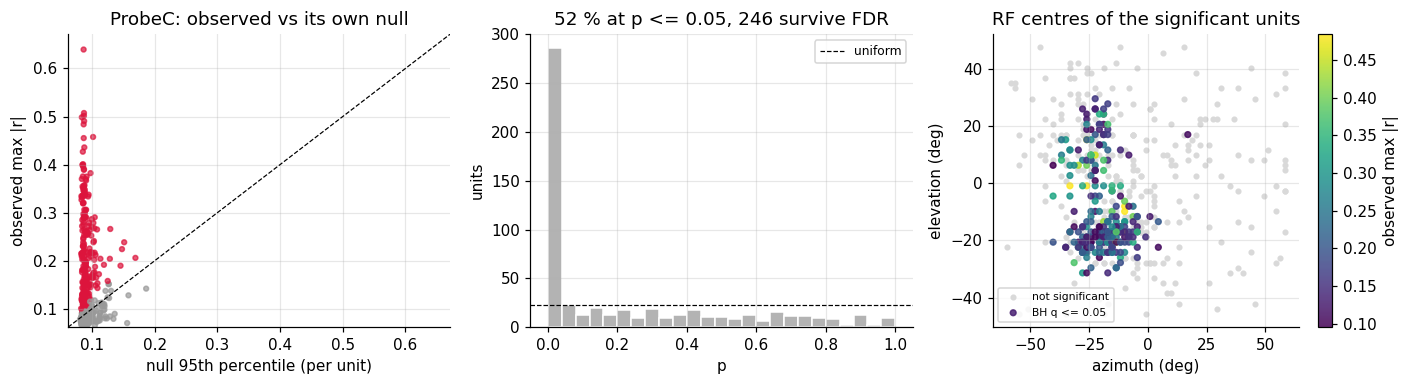

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(13, 3.6))

ax1.scatter(rf.null_p95, rf.max_obs, c=np.where(rf.significant, 'crimson', '0.6'),
            s=10, alpha=.7)
lims = [min(rf.null_p95.min(), rf.max_obs.min()) * .95,
        max(rf.null_p95.max(), rf.max_obs.max()) * 1.05]
ax1.plot(lims, lims, 'k--', lw=.8)
ax1.set(xlabel='null 95th percentile (per unit)', ylabel='observed max |r|',
        title='ProbeC: observed vs its own null', xlim=lims, ylim=lims)

ax2.hist(rf.p, bins=np.linspace(0, 1, 26), color='0.7', edgecolor='w')
ax2.axhline(len(rf) / 25, color='k', ls='--', lw=.8, label='uniform')
ax2.set(xlabel='p', ylabel='units',
        title=f'{100 * (rf.p <= .05).mean():.0f} % at p <= 0.05, '
              f'{rf.significant.sum()} survive FDR')
ax2.legend(fontsize=8)

# q is at the BH floor for almost every survivor, so colour by the effect size
sig = rf[rf.significant]
ax3.scatter(rf.x_deg[~rf.significant], rf.y_deg[~rf.significant], s=9,
            c='0.85', label='not significant')
sc = ax3.scatter(sig.x_deg, sig.y_deg, s=14, c=sig.max_obs, cmap='viridis',
                 vmax=float(np.quantile(sig.max_obs, .98)), alpha=.85,
                 label='BH q <= 0.05')
plt.colorbar(sc, ax=ax3, label='observed max |r|')
ax3.set(xlabel='azimuth (deg)', ylabel='elevation (deg)',
        title='RF centres of the significant units')
ax3.legend(fontsize=7, loc='lower left')
plt.tight_layout()
plt.show()

## 9. Things to keep in mind

* **The grid must match.** The single easiest way to get a wrong answer.
  `read_null_sweep` / `--sweep-from-null` exist so the grid travels with the null
  file instead of being retyped.
* **The fitted p is an extrapolation.** Below `1/(1+K)` nothing is measured. It is
  validated against counting in the overlap region and against its own draws by
  the Q-Q residual, but a fitted p of 1e-40 means "far beyond anything these
  surrogates produced", not a calibrated probability. Report the counted p where
  it resolves, and raise `--n-surrogates` rather than leaning on the fit.
* **The family is a choice.** Section 6 pools the whole session, which is the
  strictest option; per structure would be more permissive and arguably more
  interpretable, since a probe is an instrument and a session is a mixture of
  populations. What must not happen is choosing the family after seeing the
  p-values.
* **Per-unit control is already in the p-value.** It covers every filter and sweep
  point within a unit. Correcting across units is the BH step on top.
* **Phase specific.** Phase 0 and phase 1 have separate nulls, and testing both and
  keeping the better one is two tests, not one. Same for the two trials.
* **The screen.** Units with `n_spikes < min_spikes` are absent from the null files
  but present in the results. Always join on `unit_id`.
* **Same recipe for the ophys nulls.** `compute_null_distribution_mesoscope.py` and
  `compute_null_distribution_slap2.py` write this identical format, with `modality`,
  `signal` and (for SLAP2) `dmd` / `channel` / `min_coverage` attributes, and with
  `n_spikes` holding an activity count instead of a spike count — `activity_measure`
  in the attributes says which. Everything from section 4 on applies unchanged.
* **The cluster copies** live under
  `<workspace>/allen/rf/zebra/nullresults/<modality>/<session>/`, beside
  `rawresults/` and `optimized/`.

In [ ]:
# The helpers worth reusing elsewhere:
#     unit_stats(path)              -> per-unit statistic, null and both p-values
#     session_stats(trial, phase)   -> every probe pooled, with the BH q-value
#     rf_table(probe)               -> the same, joined to the RF parameters
#
# One row per (probe, trial, phase, unit) for the whole session:
everything = pd.concat(
    [rf_table(pr, trial=t, phase=p, session_df=d)
     for (t, p), d in runs.items()
     for pr in sorted(d.probe.unique())],
    ignore_index=True)

print(f'{len(everything)} (unit, trial, phase) rows, '
      f'{everything.unit_id.nunique()} unique units')
print(f'significant at q <= {Q_LEVEL}: {int(everything.significant.sum())} rows, '
      f'{everything[everything.significant].unit_id.nunique()} unique units\n')

counts = (everything.groupby(['probe', 'unit_id'])['significant']
                    .agg(n_sig='sum', n_runs='size'))
both_ways = counts[(counts.n_runs == 4) & (counts.n_sig == 4)]
print('significant in all 4 (trial, phase) runs, per probe:')
print(both_ways.groupby('probe').size().to_string())

# everything.to_csv('../results/zebra/null_pvalues_%s.csv' % SESSION, index=False)

12514 (unit, trial, phase) rows, 3255 unique units
significant at q <= 0.05: 1920 rows, 574 unique units

significant in all 4 (trial, phase) runs, per probe:
probe
ProbeA      2
ProbeB     18
ProbeC    231
ProbeD    142
ProbeF      1
